In [1]:
%pip install "medprep-starter[medical] @ git+https://github.com/Z-bros/Med_Im_Prepper.git"
import medprep
from medprep import MedicalPipeline, PreprocessConfig

print("medprep loaded from:", medprep.__file__)

  Cloning https://github.com/Z-bros/Med_Im_Prepper.git to /tmp/pip-install-h_u49b2v/medprep-starter_bf0cd4f96ce9482ca1f6b6b6fc8f34d6
  Running command git clone --filter=blob:none --quiet https://github.com/Z-bros/Med_Im_Prepper.git /tmp/pip-install-h_u49b2v/medprep-starter_bf0cd4f96ce9482ca1f6b6b6fc8f34d6
  Resolved https://github.com/Z-bros/Med_Im_Prepper.git to commit 9941c68c3ad771c751c5be9e4c30e7fff82ef9b4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for medprep-starter: filename=medprep_starter-0.1.0-py3-none-any.whl size=12117 sha256=c3ceeafb6820d5ef8ef09a5e90358966dc5dbb0daa7b3ac4baeddef1678fbfee
  Stored in directory: /tmp/pip-ephem-wheel-cache-86terwy4/wheels/de/f5/8a/e994093450acec394d6073104c38f80d0b53cbec90fc216d93
Successfully built medprep-starter
Note: you may need to restart the kernel to use updated packages.
medprep loaded from: /usr/local/lib/python3.12/dist-pac

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
from pydicom.pixels import apply_modality_lut

ROOT = Path(
    "/kaggle/input/competitions/rsna-knee-abnormality-detection"
)

train = pd.read_csv(ROOT / "train.csv")
series = pd.read_csv(ROOT / "train_series.csv")

# Select the first study and its first series, as before
study_id = train.iloc[0]["StudyInstanceUID"]
study_series = series.loc[series["StudyInstanceUID"] == study_id]
selected_series = study_series.iloc[0]
series_id = selected_series["SeriesInstanceUID"]

series_folder = ROOT / "train_series" / study_id / series_id
files = sorted(series_folder.glob("*.dcm"))

if not files:
    raise FileNotFoundError(f"No DICOM files found in {series_folder}")

# Read headers to establish physical slice order
headers = [
    pydicom.dcmread(path, stop_before_pixels=True)
    for path in files
]

orientations = np.array(
    [ds.ImageOrientationPatient for ds in headers],
    dtype=float,
)

if not np.allclose(
    orientations, orientations[0], atol=1e-4, rtol=0
):
    raise ValueError("Slice orientations differ; inspect before stacking.")

normal = np.cross(orientations[0, :3], orientations[0, 3:])
normal /= np.linalg.norm(normal)

positions = np.array(
    [ds.ImagePositionPatient for ds in headers],
    dtype=float,
)

order = np.argsort(positions @ normal)
ordered_files = [files[i] for i in order]

# Decode and rescale each slice once
slices = []

for path in ordered_files:
    ds = pydicom.dcmread(path)
    rescaled = apply_modality_lut(ds.pixel_array, ds)
    slices.append(rescaled.astype(np.float32))

volume = np.stack(slices)

print("Plane:", selected_series["Anatomical_Plane"])
print("Volume shape:", volume.shape)
print("Data type:", volume.dtype)
print("Rescaled intensity range:", volume.min(), "to", volume.max())

Plane: Sagittal
Volume shape: (22, 512, 512)
Data type: float32
Rescaled intensity range: 0.0 to 2693.0437


# Apply for Normalization

In [3]:
config = PreprocessConfig(
    spatial_dims=3,
    normalization="minmax",
    percentiles=None,
    target_shape=None,
    nonzero_stats=False,
)

pipeline = MedicalPipeline(preprocessing=config)

result = pipeline(volume, training=False)
volume_normalized = result["image"]

print("Shape:", volume_normalized.shape)
print("Data type:", volume_normalized.dtype)
print("Original range:", volume.min(), "to", volume.max())
print(
    "Normalized range:",
    volume_normalized.min(), "to", volume_normalized.max()
)

Shape: (22, 512, 512)
Data type: float32
Original range: 0.0 to 2693.0437
Normalized range: 0.0 to 1.0


In [4]:
clipped_pipeline = MedicalPipeline(
    preprocessing=PreprocessConfig(
        spatial_dims=3,
        normalization="minmax",
        percentiles=(1, 99),
        target_shape=None,
        nonzero_stats=False,
    )
)

clipped_result = clipped_pipeline(volume, training=False)
volume_clipped = clipped_result["image"]

print("Clipping bounds:", np.percentile(volume, [1, 99]))
print("Output range:", volume_clipped.min(), "to", volume_clipped.max())

Clipping bounds: [   0.         1561.14782715]
Output range: 0.0 to 1.0


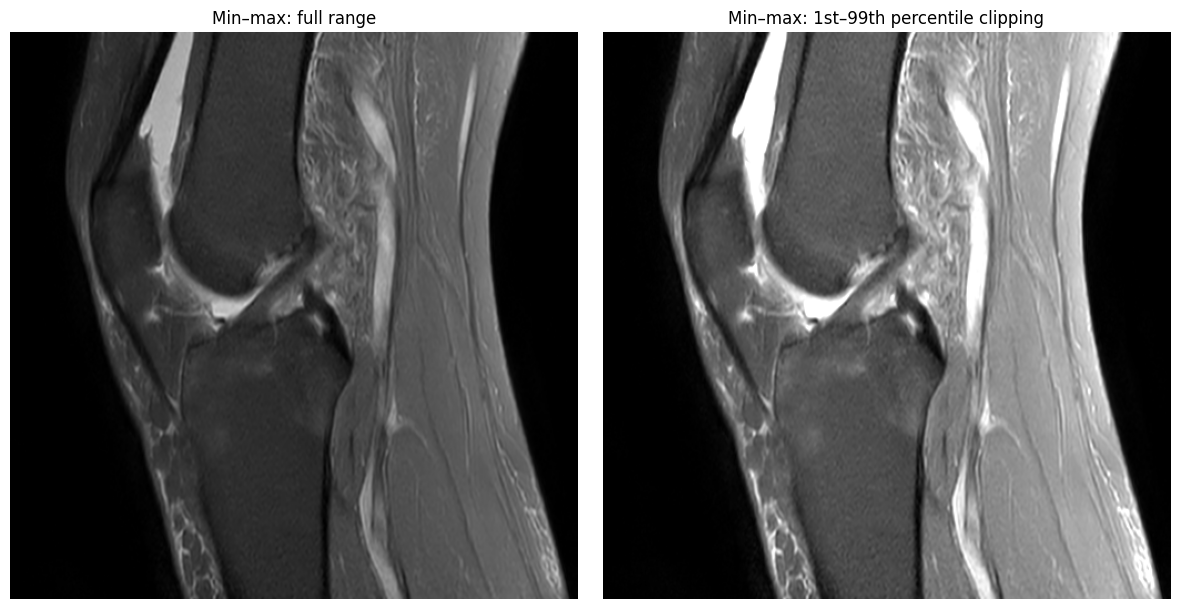

In [5]:
slice_index = len(volume) // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

comparisons = [
    (volume_normalized, "Min–max: full range"),
    (volume_clipped, "Min–max: 1st–99th percentile clipping"),
]

for ax, (data, title) in zip(axes, comparisons):
    ax.imshow(
        data[slice_index],
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
resize_pipeline = MedicalPipeline(
    preprocessing=PreprocessConfig(
        spatial_dims=2,
        target_shape=(224, 224),
        resize_mode="pad",
        normalization="none",
    )
)

volume_resized = np.stack([
    resize_pipeline(slice_image, training=False)["image"]
    for slice_image in volume_clipped
])

print("Before:", volume_clipped.shape)
print("After:", volume_resized.shape)

Before: (22, 512, 512)
After: (22, 224, 224)


# Apply for resizing

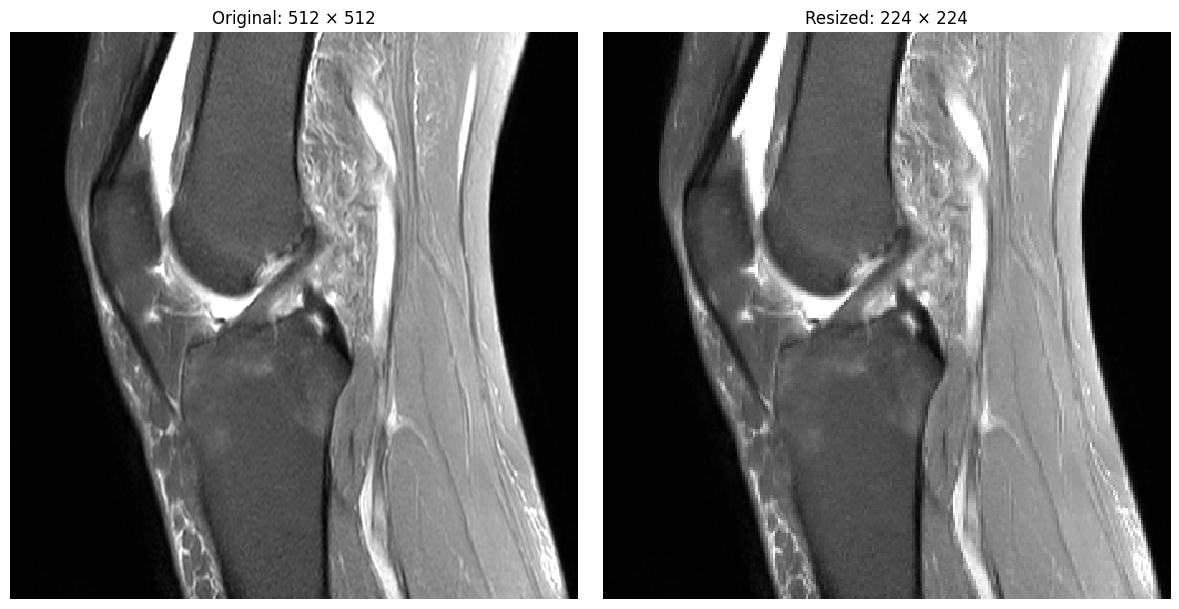

In [7]:
slice_index = len(volume_clipped) // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, data, title in zip(
    axes,
    [volume_clipped, volume_resized],
    ["Original: 512 × 512", "Resized: 224 × 224"],
):
    ax.imshow(
        data[slice_index],
        cmap="gray",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

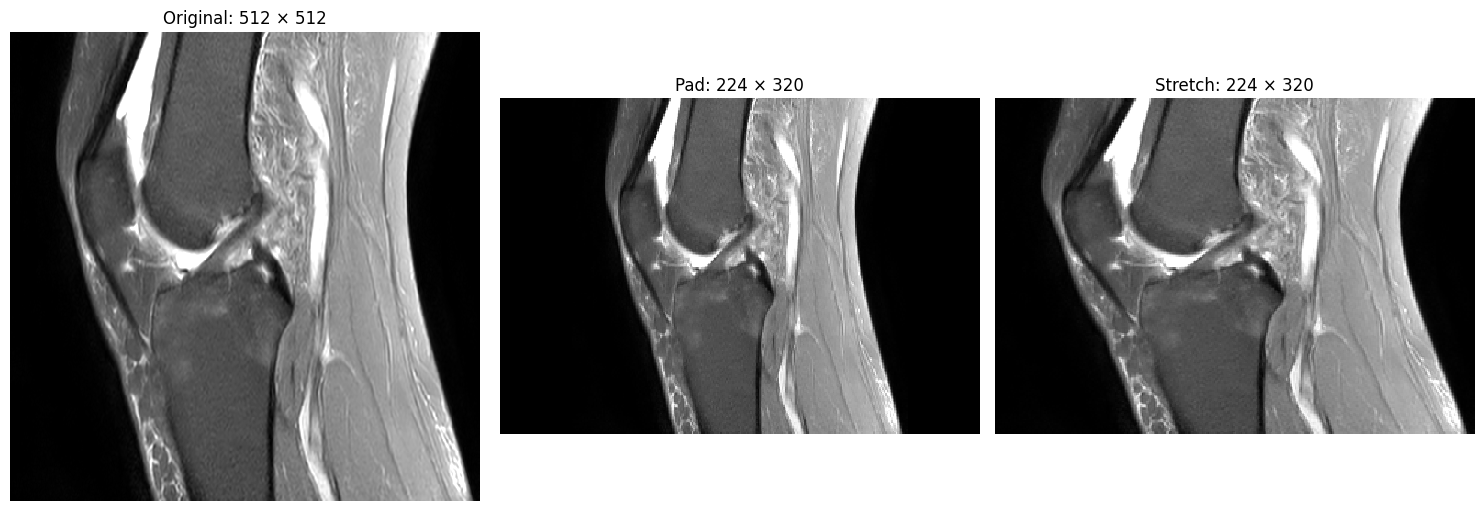

In [8]:
slice_index = len(volume_clipped) // 2
source_slice = volume_clipped[slice_index]

outputs = {}

for mode in ["pad", "stretch"]:
    demo_pipeline = MedicalPipeline(
        preprocessing=PreprocessConfig(
            spatial_dims=2,
            target_shape=(224, 320),
            resize_mode=mode,
            normalization="none",
        )
    )

    outputs[mode] = demo_pipeline(
        source_slice, training=False
    )["image"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

comparisons = [
    (source_slice, "Original: 512 × 512"),
    (outputs["pad"], "Pad: 224 × 320"),
    (outputs["stretch"], "Stretch: 224 × 320"),
]

for ax, (data, title) in zip(axes, comparisons):
    ax.imshow(
        data,
        cmap="gray",
        vmin=0,
        vmax=1,
        aspect="equal",
        interpolation="nearest",
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

Streched 224 x 320 image changes the anatomy, so we're going to use the pad 224 x 320 or straight 224 x 224. Due to limited computational power, smaller size is preferrable. Hence, image with is 224 x 224 px is preferrable.  

In [9]:
summary = pd.DataFrame([
    {
        "Stage": name,
        "Shape": data.shape,
        "Data type": str(data.dtype),
        "Minimum": float(data.min()),
        "Maximum": float(data.max()),
        "All values finite": bool(np.isfinite(data).all()),
    }
    for name, data in [
        ("Rescaled input", volume),
        ("Min–max normalized", volume_normalized),
        ("Clipped + normalized", volume_clipped),
        ("Resized", volume_resized),
    ]
])

display(summary)

assert volume_resized.shape == (volume.shape[0], 224, 224)
assert volume_resized.dtype == np.float32
assert np.isfinite(volume_resized).all()
assert volume_resized.min() >= -1e-6
assert volume_resized.max() <= 1 + 1e-6

print("Output checks passed.")

,Stage,Shape,Data type,Minimum,Maximum,All values finite
0,Rescaled input,"(22, 512, 512)",float32,0.0,2693.043701,True
1,Min–max normalized,"(22, 512, 512)",float32,0.0,1.000000,True
2,Clipped + normalized,"(22, 512, 512)",float32,0.0,1.000000,True
3,Resized,"(22, 224, 224)",float32,0.0,1.000000,True


Output checks passed.


# The Take:
- Preprocessing was demonstrated on one sagittal series containing 22 slices.
- Min–max normalization used shared statistics across the entire volume.
- Clipping at the 1st and 99th percentiles increased visible contrast while removing intensity differences above the upper threshold.
- Each slice was resized from 512 × 512 to 224 × 224, reducing fine detail.
- Padding preserves array proportions when input and target aspect ratios differ; stretching can distort them.
- These operations do not standardize physical spacing or update DICOM geometry.
- Clipping thresholds and input size remain experimental choices to evaluate during model validation.

# Save the volume_resized for image augmentation

In [10]:
np.save(
    "/kaggle/working/volume_resized.npy",
    volume_resized,
)